# Predição de Preço de Automóveis com Regressão Linear Múltipla

## Projeto de Modelagem Preditiva

### Objetivo

Desenvolver modelos de Regressão Linear Múltipla para estimar o preço de automóveis a partir de suas características técnicas.



# 1. Importação das Bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from scipy import stats

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. Carregamento da Base de Dados

In [3]:
df = pd.read_csv('preco_carro (3).csv')

# 3. Visualização Inicial dos Dados

In [4]:
df.head()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


### Estrutura da Base de Dados

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   v.id           1000 non-null   int64  
 1   on road old    1000 non-null   int64  
 2   on road now    1000 non-null   int64  
 3   years          1000 non-null   int64  
 4   km             1000 non-null   int64  
 5   rating         1000 non-null   int64  
 6   condition      1000 non-null   int64  
 7   economy        1000 non-null   int64  
 8   top speed      1000 non-null   int64  
 9   hp             1000 non-null   int64  
 10  torque         1000 non-null   int64  
 11  current price  1000 non-null   float64
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


# 3. Análise Descritiva

In [6]:
df.describe()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000
mean,500.500000,601648.286000,799131.3970,4.561000,100274.430000,2.988000,5.592000,11.625000,166.89300,84.54600,103.423000,308520.24250
std,288.819436,58407.246204,57028.9502,1.719079,29150.463233,1.402791,2.824449,2.230549,19.28838,20.51694,21.058716,126073.25915
min,1.000000,500265.000000,700018.0000,2.000000,50324.000000,1.000000,1.000000,8.000000,135.00000,50.00000,68.000000,28226.50000
25%,250.750000,548860.500000,750997.7500,3.000000,74367.500000,2.000000,3.000000,10.000000,150.00000,67.00000,85.000000,206871.75000
50%,500.500000,601568.000000,798168.0000,5.000000,100139.500000,3.000000,6.000000,12.000000,166.00000,84.00000,104.000000,306717.75000
75%,750.250000,652267.250000,847563.2500,6.000000,125048.000000,4.000000,8.000000,13.000000,184.00000,102.00000,121.000000,414260.87500
max,1000.000000,699859.000000,899797.0000,7.000000,149902.000000,5.000000,10.000000,15.000000,200.00000,120.00000,140.000000,584267.50000


## Verificação de Valores Ausentes


In [7]:
df.isnull().sum()

,0
v.id,0
on road old,0
on road now,0
years,0
km,0
rating,0
condition,0
economy,0
top speed,0
hp,0


### Distribuição das Variáveis

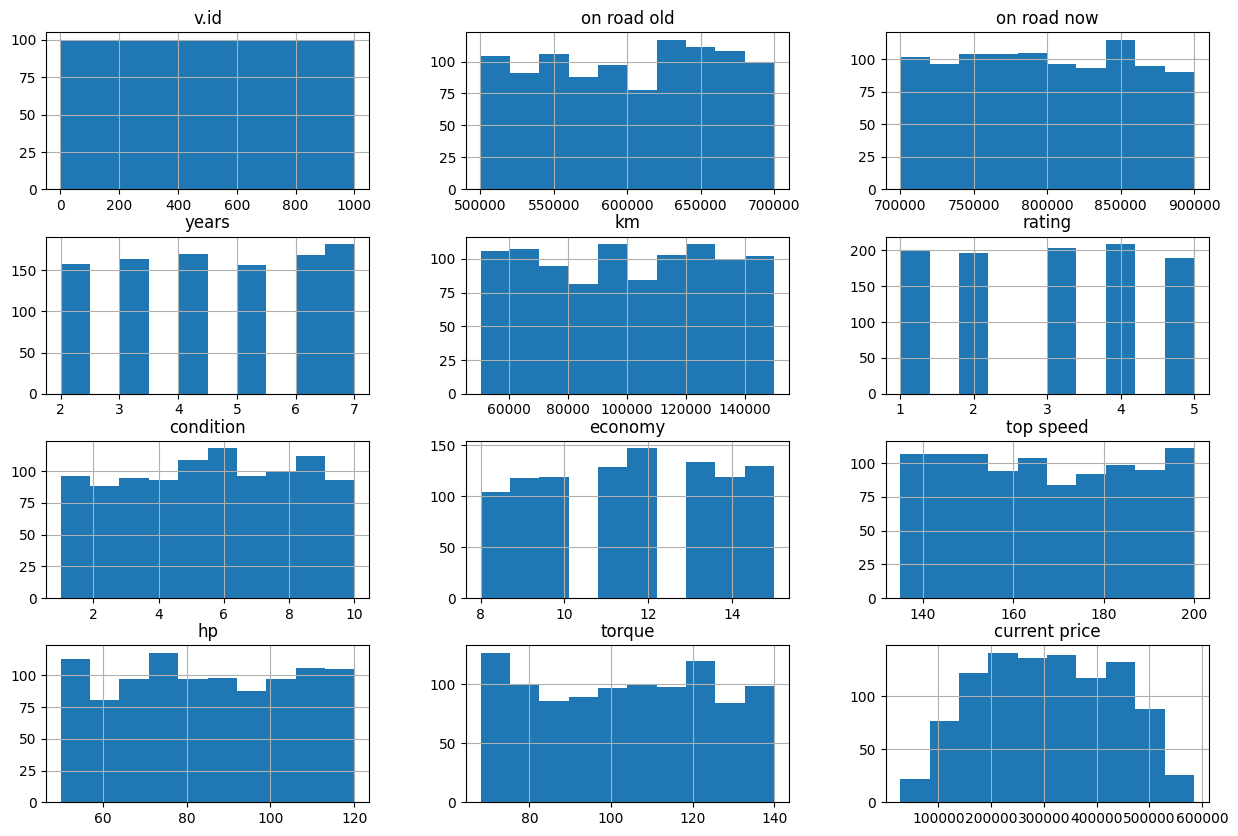

In [8]:
df.hist(figsize=(15,10))
plt.show()

### Interpretação da Análise Descritiva

A base de dados é composta por 1000 observações e 12 variáveis numéricas relacionadas às características técnicas e ao preço dos automóveis.

A análise das estatísticas descritivas mostrou que a variável alvo **current price** apresenta preço médio de aproximadamente 308.520,24, com valores variando entre 28.226,50 e 584.267,50, indicando ampla variabilidade entre os veículos analisados.

As variáveis relacionadas ao valor de mercado dos veículos novos (**on road old** e **on road now**) também apresentaram grande dispersão, sugerindo potencial influência sobre o preço atual dos automóveis.

A verificação de valores ausentes demonstrou que nenhuma variável possui registros nulos, permitindo a utilização integral da base sem necessidade de tratamentos adicionais.

A análise dos histogramas indicou distribuições relativamente equilibradas para a maioria das variáveis da base de dados. Observou-se variabilidade adequada entre as características dos veículos e no preço atual dos automóveis, fornecendo informações suficientes para a construção de modelos preditivos.

De modo geral, os dados apresentaram comportamento compatível com a aplicação de técnicas de regressão linear múltipla, permitindo a investigação das relações entre as características dos veículos e seu preço atual.

Dessa forma, conclui-se que a base possui boa qualidade, ausência de valores faltantes e variabilidade suficiente para o desenvolvimento de modelos preditivos para estimativa do preço atual dos automóveis.

# 4. Correlação e Covariância


In [9]:
correlacao = df.corr()

correlacao

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
v.id,1.000000,-0.029926,-0.030787,-0.034255,0.047400,-0.018263,-0.038548,0.047137,0.001613,-0.006997,-0.000632,-0.059460
on road old,-0.029926,1.000000,0.034113,0.007207,0.007488,-0.050717,-0.015682,-0.030097,-0.023816,-0.049266,0.008950,0.233035
on road now,-0.030787,0.034113,1.000000,0.004609,-0.053202,0.028280,-0.005043,-0.015880,0.012699,-0.012719,0.017955,0.282793
years,-0.034255,0.007207,0.004609,1.000000,-0.002089,0.027285,0.053579,0.050220,0.025148,-0.003272,0.028859,-0.011854
km,0.047400,0.007488,-0.053202,-0.002089,1.000000,-0.039930,-0.013640,0.032680,0.026450,-0.052918,0.013566,-0.935924
rating,-0.018263,-0.050717,0.028280,0.027285,-0.039930,1.000000,0.015943,-0.009757,-0.042222,-0.022623,0.004408,0.035038
condition,-0.038548,-0.015682,-0.005043,0.053579,-0.013640,0.015943,1.000000,0.058788,0.018472,-0.071552,0.047805,0.110108
economy,0.047137,-0.030097,-0.015880,0.050220,0.032680,-0.009757,0.058788,1.000000,-0.059402,-0.016782,0.041632,-0.034711
top speed,0.001613,-0.023816,0.012699,0.025148,0.026450,-0.042222,0.018472,-0.059402,1.000000,0.057827,-0.019697,-0.027993
hp,-0.006997,-0.049266,-0.012719,-0.003272,-0.052918,-0.022623,-0.071552,-0.016782,0.057827,1.000000,-0.013817,0.030238


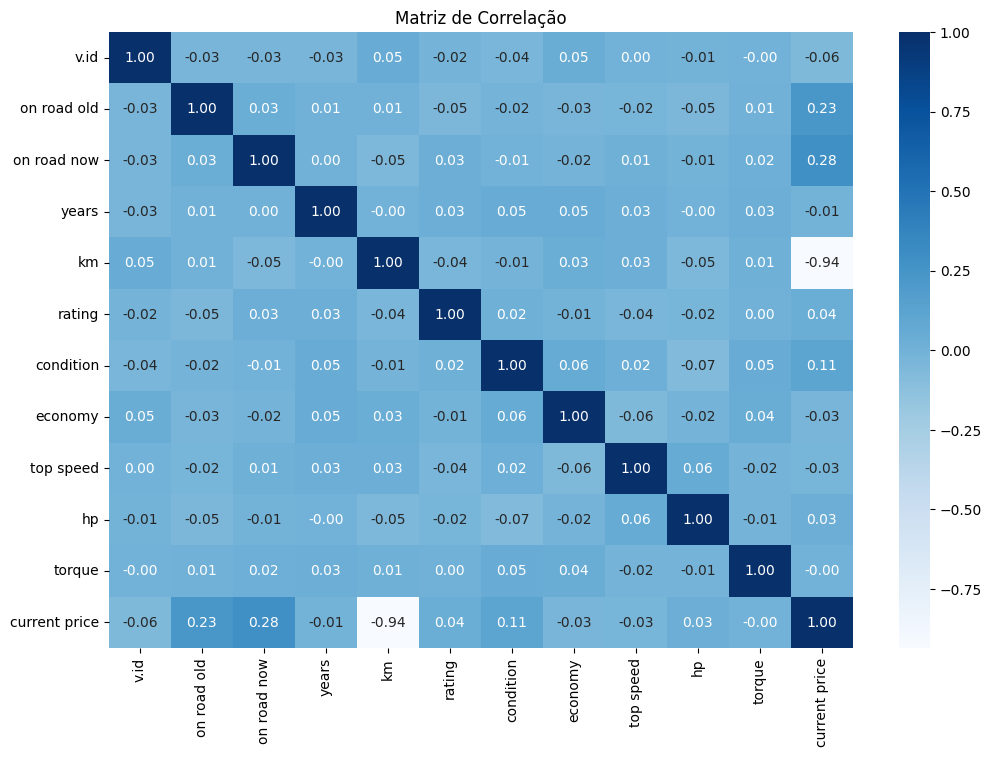

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

In [11]:
covariancia = df.cov()

covariancia

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
v.id,8.341667e+04,-5.048332e+05,-5.070998e+05,-17.007508,3.990728e+05,-7.399399,-31.445445,30.366867,8.988488,-41.463463,-3.846346,-2.165096e+06
on road old,-5.048332e+05,3.411406e+09,1.136275e+08,723.631185,1.274980e+07,-4155.436004,-2587.026338,-3921.005756,-26830.347746,-59037.689846,11008.687710,1.715974e+09
on road now,-5.070998e+05,1.136275e+08,3.252301e+09,451.837120,-8.844456e+07,2262.387151,-812.382406,-2020.082207,13969.286766,-14882.559321,21563.603673,2.033231e+09
years,-1.700751e+01,7.236312e+02,4.518371e+02,2.955234,-1.046949e+02,0.065798,0.260148,0.192568,0.833861,-0.115421,1.044742,-2.569170e+03
km,3.990728e+05,1.274980e+07,-8.844456e+07,-104.694925,8.497495e+08,-1632.826667,-1123.013574,2124.906156,14872.065075,-31649.363143,8327.856967,-3.439609e+09
rating,-7.399399e+00,-4.155436e+03,2.262387e+03,0.065798,-1.632827e+03,1.967824,0.063167,-0.030531,-1.142426,-0.651099,0.130206,6.196546e+03
condition,-3.144545e+01,-2.587026e+03,-8.123824e+02,0.260148,-1.123014e+03,0.063167,7.977514,0.370370,1.006350,-4.146378,2.843427,3.920823e+04
economy,3.036687e+01,-3.921006e+03,-2.020082e+03,0.192568,2.124906e+03,-0.030531,0.370370,4.975350,-2.555681,-0.768018,1.955581,-9.761051e+03
top speed,8.988488e+00,-2.683035e+04,1.396929e+04,0.833861,1.487207e+04,-1.142426,1.006350,-2.555681,372.041593,22.884306,-8.000740,-6.807131e+04
hp,-4.146346e+01,-5.903769e+04,-1.488256e+04,-0.115421,-3.164936e+04,-0.651099,-4.146378,-0.768018,22.884306,420.944829,-5.969928,7.821565e+04


### Interpretação da Correlação e Covariância

A análise de correlação mostrou que a variável **km** apresenta a relação mais forte com o preço atual dos automóveis, com correlação de -0,936. Esse resultado indica que veículos com maior quilometragem tendem a apresentar menor valor de mercado.

As variáveis **on road now** (0,283) e **on road old** (0,233) também apresentaram correlação positiva com o preço atual, sugerindo que veículos com maiores valores de referência tendem a possuir maior preço de revenda.

A variável **condition** apresentou correlação positiva de 0,110, indicando que veículos em melhor estado de conservação tendem a possuir preços mais elevados.

As demais variáveis apresentaram correlações fracas com a variável alvo, sugerindo menor contribuição individual para explicação do preço atual dos automóveis.

A análise de covariância confirmou os padrões observados na matriz de correlação, reforçando a influência da quilometragem e dos preços de referência sobre o valor atual dos veículos.

# 5. Modelo 1 - Todas as Variáveis

In [12]:
X = df.drop(columns=['v.id', 'current price'])

y = df['current price']

X = sm.add_constant(X)

modelo1 = sm.OLS(y, X).fit()

modelo1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          current price   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.072e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:17:30   Log-Likelihood:                -10488.
No. Observations:                1000   AIC:                         2.100e+04
Df Residuals:                     989   BIC:                         2.105e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.383e+04   6046.330     -2.287      0.022   -2.57e+04   -1961.431
on road old     0.5057      0.005    106.452      0.000       0.496       0.515
on road now     0.5003      0.005    102.949      0.000       0.491       0.510
years       -1622.3890    161.327    -10.057      0.000   -1938.972   -1305.806
km             -3.9961      0.010   -419.521      0.000      -4.015      -3.977
rating        230.9884    197.816      1.168      0.243    -157.199     619.175
condition    4628.4689     98.541     46.970      0.000    4435.096    4821.842
economy        62.4643    124.716      0.501      0.617    -182.275     307.203
top speed     -14.5732     14.413     -1.011      0.312     -42.856      13.710
hp             20.3599     13.569      1.500      0.134      -6.268      46.988
torque         -1.7328     13.157     -0.132      0.895     -27.551      24.086
==============================================================================
Omnibus:                       83.060   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               96.422
Skew:                           0.736   Prob(JB):                     1.15e-21
Kurtosis:                       2.620   Cond. No.                     2.20e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.2e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretação do Modelo 1

O Modelo 1 foi construído utilizando todas as variáveis explicativas disponíveis na base de dados, exceto o identificador do veículo (v.id).

O coeficiente de determinação (R² = 0,995) indica que aproximadamente 99,5% da variação do preço atual dos automóveis é explicada pelas variáveis incluídas no modelo, demonstrando excelente capacidade preditiva.

As variáveis on road old, on road now, years, km e condition apresentaram significância estatística (p-valor < 0,05), indicando contribuição relevante para a explicação do preço dos

# 6. Modelo 2 – Três Variáveis Mais Correlacionadas

In [13]:
X2 = df[['km', 'on road now', 'on road old']]

y = df['current price']

X2 = sm.add_constant(X2)

modelo2 = sm.OLS(y, X2).fit()

modelo2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          current price   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                 2.079e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:24:45   Log-Likelihood:                -11087.
No. Observations:                1000   AIC:                         2.218e+04
Df Residuals:                     996   BIC:                         2.220e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        9725.7449   8829.831      1.101      0.271   -7601.461    2.71e+04
km             -4.0034      0.017   -232.651      0.000      -4.037      -3.970
on road now     0.4988      0.009     56.675      0.000       0.482       0.516
on road old     0.5014      0.009     58.426      0.000       0.485       0.518
==============================================================================
Omnibus:                      210.448   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              354.975
Skew:                           1.389   Prob(JB):                     8.28e-78
Kurtosis:                       3.898   Cond. No.                     1.78e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.78e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretação do Modelo 2

O Modelo 2 foi construído utilizando as três variáveis mais correlacionadas com o preço atual dos automóveis: km, on road now e on road old.

O coeficiente de determinação (R² = 0,984) indica que aproximadamente 98,4% da variação do preço dos veículos é explicada por essas três variáveis, demonstrando excelente capacidade preditiva mesmo com um número reduzido de preditores.

A variável km apresentou coeficiente negativo, indicando que o aumento da quilometragem tende a reduzir o valor de mercado dos automóveis. Já as variáveis on road now e on road old apresentaram coeficientes positivos, sugerindo que veículos com maiores preços de referência tendem a possuir maior preço atual.

Todas as variáveis explicativas apresentaram significância estatística (p-valor < 0,05), demonstrando contribuição relevante para a previsão do preço dos veículos.

Observa-se que o desempenho do Modelo 2 permaneceu muito próximo ao Modelo 1, mesmo utilizando apenas três variáveis, indicando que grande parte da capacidade explicativa do modelo está concentrada nesses preditores.

# 7. Modelo 3 – Cinco Variáveis Mais Correlacionadas

In [14]:
X3 = df[['km',
         'on road now',
         'on road old',
         'condition',
         'rating']]

y = df['current price']

X3 = sm.add_constant(X3)

modelo3 = sm.OLS(y, X3).fit()

modelo3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          current price   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 3.763e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:27:12   Log-Likelihood:                -10539.
No. Observations:                1000   AIC:                         2.109e+04
Df Residuals:                     994   BIC:                         2.112e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.001e+04   5197.473     -3.850      0.000   -3.02e+04   -9808.943
km             -3.9970      0.010   -401.036      0.000      -4.017      -3.977
on road now     0.4998      0.005     98.101      0.000       0.490       0.510
on road old     0.5050      0.005    101.541      0.000       0.495       0.515
condition    4565.4356    102.664     44.470      0.000    4363.972    4766.899
rating        177.5388    207.172      0.857      0.392    -229.006     584.083
==============================================================================
Omnibus:                       55.912   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.211
Skew:                           0.593   Prob(JB):                     3.10e-14
Kurtosis:                       2.707   Cond. No.                     1.81e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretação do Modelo 3

O Modelo 3 foi construído utilizando as cinco variáveis mais correlacionadas com o preço atual dos automóveis: km, on road now, on road old, condition e rating.

O coeficiente de determinação (R² = 0,995) indica que aproximadamente 99,5% da variação do preço atual dos veículos é explicada pelo modelo, apresentando desempenho equivalente ao Modelo 1.

As variáveis km, on road now, on road old e condition apresentaram significância estatística (p-valor < 0,05), demonstrando forte contribuição para a previsão do preço dos automóveis.

A variável rating não apresentou significância estatística (p-valor = 0,392), indicando que sua contribuição individual para o modelo é limitada quando considerada juntamente com as demais variáveis.

Observa-se que o Modelo 3 alcançou elevado poder preditivo utilizando apenas cinco variáveis, demonstrando que a maior parte da explicação do preço dos automóveis está concentrada nesses preditores.

# 8. Análise de Resíduos

In [16]:
residuos = modelo3.resid

previstos = modelo3.fittedvalues

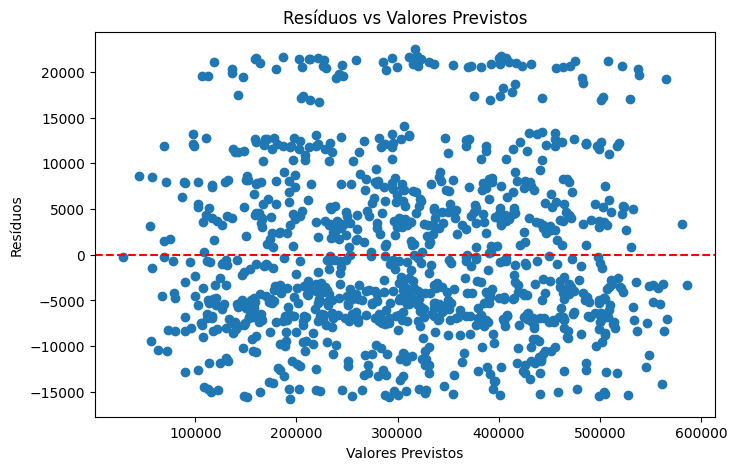

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(previstos, residuos)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')

plt.title('Resíduos vs Valores Previstos')

plt.show()

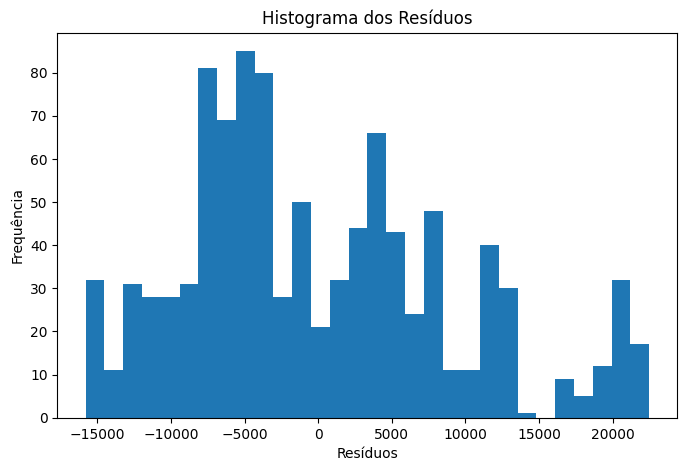

In [18]:
plt.figure(figsize=(8,5))

plt.hist(residuos, bins=30)

plt.title('Histograma dos Resíduos')

plt.xlabel('Resíduos')
plt.ylabel('Frequência')

plt.show()

In [19]:
stats.shapiro(residuos)

ShapiroResult(statistic=np.float64(0.9553046658770755), pvalue=np.float64(6.778126355527978e-17))

### Interpretação da Análise de Resíduos

A análise gráfica dos resíduos permite verificar se os erros do modelo estão distribuídos de forma aleatória em torno de zero, condição desejável para modelos de regressão linear.

O teste de Shapiro-Wilk apresentou p-valor inferior a 0,05 (p < 0,001), indicando rejeição da hipótese de normalidade dos resíduos. Dessa forma, os resíduos não seguem perfeitamente uma distribuição normal.

Entretanto, considerando o elevado tamanho da amostra (1000 observações) e o excelente desempenho do modelo (R² = 0,995), pequenas violações da normalidade tendem a ter impacto reduzido sobre a capacidade preditiva do modelo.

De modo geral, os resultados indicam que o modelo apresenta bom ajuste aos dados, embora a hipótese de normalidade dos resíduos não seja totalmente atendida.

# 9. Análise de Multicolinearidade

In [20]:
X_vif = df[['km',
            'on road now',
            'on road old',
            'condition',
            'rating']]

X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()

vif['Variável'] = X_vif.columns

vif['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif

,Variável,VIF
0,const,321.815858
1,km,1.004556
2,on road now,1.004858
3,on road old,1.004120
4,condition,1.000676
5,rating,1.005162


### Interpretação da Análise de Multicolinearidade

A análise do Fator de Inflação da Variância (VIF) demonstrou que todas as variáveis explicativas apresentaram valores próximos de 1.

Os resultados obtidos foram:

- km: 1,005
- on road now: 1,005
- on road old: 1,004
- condition: 1,001
- rating: 1,005

Como todos os valores estão muito abaixo do limite de 5, conclui-se que não há evidências de multicolinearidade entre as variáveis explicativas do modelo.

Dessa forma, as estimativas dos coeficientes podem ser consideradas estáveis e confiáveis, não havendo necessidade de remoção de variáveis por problemas de correlação excessiva entre os preditores.

# 10. Análise de Outliers

### Identificação de Outliers

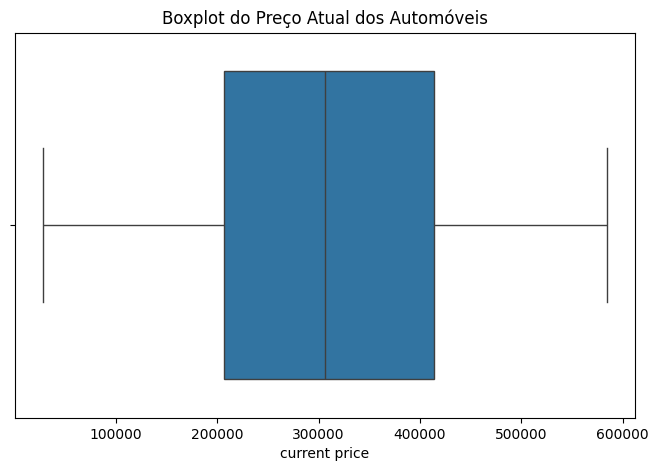

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['current price'])

plt.title('Boxplot do Preço Atual dos Automóveis')

plt.show()

### Interpretação da Análise de Outliers

O boxplot da variável current price foi utilizado para verificar a presença de possíveis valores discrepantes (outliers) na base de dados.

A análise gráfica não evidenciou a existência de outliers, uma vez que não foram observados pontos isolados além dos limites do boxplot. Os valores encontram-se distribuídos dentro da faixa esperada para a variável.

Observa-se ainda que a mediana está posicionada aproximadamente no centro da distribuição, sugerindo relativa simetria dos dados em relação ao preço atual dos automóveis.

Dessa forma, conclui-se que não há evidências visuais de observações extremas capazes de comprometer o ajuste do modelo de regressão, não sendo necessária a remoção de registros da base de dados.

# 11. Comparação dos Modelos

In [22]:
comparacao = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Modelo 3'],
    'Variáveis Utilizadas': [10, 3, 5],
    'R²': [
        modelo1.rsquared,
        modelo2.rsquared,
        modelo3.rsquared
    ],
    'R² Ajustado': [
        modelo1.rsquared_adj,
        modelo2.rsquared_adj,
        modelo3.rsquared_adj
    ]
})

comparacao

,Modelo,Variáveis Utilizadas,R²,R² Ajustado
0,Modelo 1,10,0.995250,0.995202
1,Modelo 2,3,0.984279,0.984232
2,Modelo 3,5,0.994745,0.994719


### Interpretação da Comparação dos Modelos

Foram construídos três modelos de regressão linear múltipla para previsão do preço atual dos automóveis.

O Modelo 1 utilizou todas as dez variáveis explicativas disponíveis na base de dados e apresentou coeficiente de determinação R² igual a 0,995250, indicando excelente capacidade preditiva.

O Modelo 2 foi construído utilizando apenas as três variáveis mais correlacionadas com a variável resposta (km, on road now e on road old), obtendo R² igual a 0,984279. Apesar da redução no número de variáveis, o modelo manteve elevado poder explicativo.

O Modelo 3 utilizou as cinco variáveis mais correlacionadas com o preço atual dos automóveis (km, on road now, on road old, condition e rating), alcançando R² igual a 0,994745.

Observa-se que os Modelos 1 e 3 apresentaram desempenhos praticamente equivalentes, com diferença mínima entre seus coeficientes de determinação. Já o Modelo 2 apresentou desempenho ligeiramente inferior, porém ainda bastante satisfatório.

Considerando o equilíbrio entre simplicidade e capacidade preditiva, o Modelo 3 pode ser considerado o mais eficiente, pois alcançou desempenho muito próximo ao Modelo 1 utilizando apenas cinco variáveis explicativas.

# 12. Conclusão Final

A análise exploratória dos dados demonstrou que a base apresenta boa qualidade, ausência de valores ausentes e variabilidade adequada para aplicação de técnicas de regressão linear múltipla.

A análise de correlação identificou a variável km como o principal fator associado ao preço atual dos automóveis, apresentando forte correlação negativa com a variável resposta. As variáveis on road now, on road old e condition também demonstraram influência relevante na previsão dos preços.

Foram desenvolvidos três modelos de regressão linear múltipla. Os resultados mostraram elevado poder explicativo em todos os casos, com destaque para os Modelos 1 e 3, que apresentaram coeficiente de determinação (R²) próximo de 0,995.

A análise de resíduos indicou bom ajuste do modelo aos dados, enquanto a análise de multicolinearidade demonstrou ausência de problemas relevantes entre as variáveis explicativas. A análise de outliers também não identificou observações extremas capazes de comprometer os resultados obtidos.

Considerando o equilíbrio entre desempenho e simplicidade, o Modelo 3 foi considerado o mais adequado para previsão do preço atual dos automóveis, pois apresentou desempenho muito próximo ao Modelo 1 utilizando apenas cinco variáveis explicativas.